- ## Imports



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14,5)
plt.rcParams["font.size"] = 12

- ## Load Synthetic Data

In [2]:
import pandas as pd

# Raw GitHub URL
DATA_URL = (
    "https://raw.githubusercontent.com/"
    "Adrita-Khan/lightcurve-imputation/main/"
    "data/analysis_data/synthetic_lightcurve.csv"
)

# Load the dataset
lightcurve = pd.read_csv(DATA_URL)

print("Dataset loaded successfully.")
print(f"Shape: {lightcurve.shape}")

lightcurve.head()

Dataset loaded successfully.
Shape: (1324, 4)


,time,ideal_flux,noise,observed_flux
0,0.0000,1.000000,0.035281,1.035281
1,0.0204,1.012783,0.008003,1.020786
2,0.0408,1.025356,0.019575,1.044930
3,0.0612,1.037512,0.044818,1.082330
4,0.0816,1.049054,0.037351,1.086405


- ## Verify the Dataset

In [3]:
required_columns = [
    "time",
    "ideal_flux",
    "noise",
    "observed_flux"
]

missing = [c for c in required_columns if c not in lightcurve.columns]

if missing:
    raise ValueError(
        f"Missing columns: {missing}"
    )

print("All required columns found.")

All required columns found.


- ## Extract Arrays

In [4]:
time = lightcurve["time"].to_numpy()

ideal_flux = lightcurve["ideal_flux"].to_numpy()

observed_flux = lightcurve["observed_flux"].to_numpy()

N = len(observed_flux)

print(f"Number of observations: {N}")

Number of observations: 1324


- ## MCAR Gap Injection Function

In [5]:
def inject_mcar(
    signal,
    missing_fraction,
    seed=0,
    block_fraction=0.5,
    min_block=5,
    max_block=50
):
    """
    Inject MCAR gaps using a mixture of
    scattered points and contiguous blocks.

    Parameters
    ----------
    signal : ndarray
        Input signal.

    missing_fraction : float
        Fraction of observations to remove.

    seed : int
        Random seed.

    block_fraction : float
        Fraction of missing observations
        allocated to block gaps.

    min_block : int
        Minimum block length.

    max_block : int
        Maximum block length.
    """

    rng = np.random.default_rng(seed)

    N = len(signal)

    signal_missing = signal.copy()

    mask = np.ones(N, dtype=int)

    total_missing = int(round(N * missing_fraction))

    n_block = int(total_missing * block_fraction)

    n_scattered = total_missing - n_block

    missing = set()

    # --------------------------
    # Create block gaps
    # --------------------------

    while len(missing) < n_block:

        block_size = rng.integers(
            min_block,
            max_block + 1
        )

        start = rng.integers(
            0,
            N - block_size
        )

        block = range(
            start,
            start + block_size
        )

        missing.update(block)

        if len(missing) > n_block:
            missing = set(
                list(missing)[:n_block]
            )

    # --------------------------
    # Create scattered gaps
    # --------------------------

    remaining = np.array(
        list(set(range(N)) - missing)
    )

    scattered = rng.choice(
        remaining,
        size=n_scattered,
        replace=False
    )

    missing.update(scattered)

    missing = np.array(
        sorted(missing)
    )

    signal_missing[missing] = np.nan

    mask[missing] = 0

    return signal_missing, mask

- ## Generate the Three Missingness Levels

In [6]:
missing_levels = [
    0.10,
    0.30,
    0.50
]

datasets = {}

for level in missing_levels:

    corrupted_signal, mask = inject_mcar(
        observed_flux,
        missing_fraction=level,
        seed=0
    )

    datasets[level] = {

        "flux": corrupted_signal,

        "mask": mask

    }

print("Gap injection completed.")

Gap injection completed.


- ## Visualize the Corrupted Light Curves

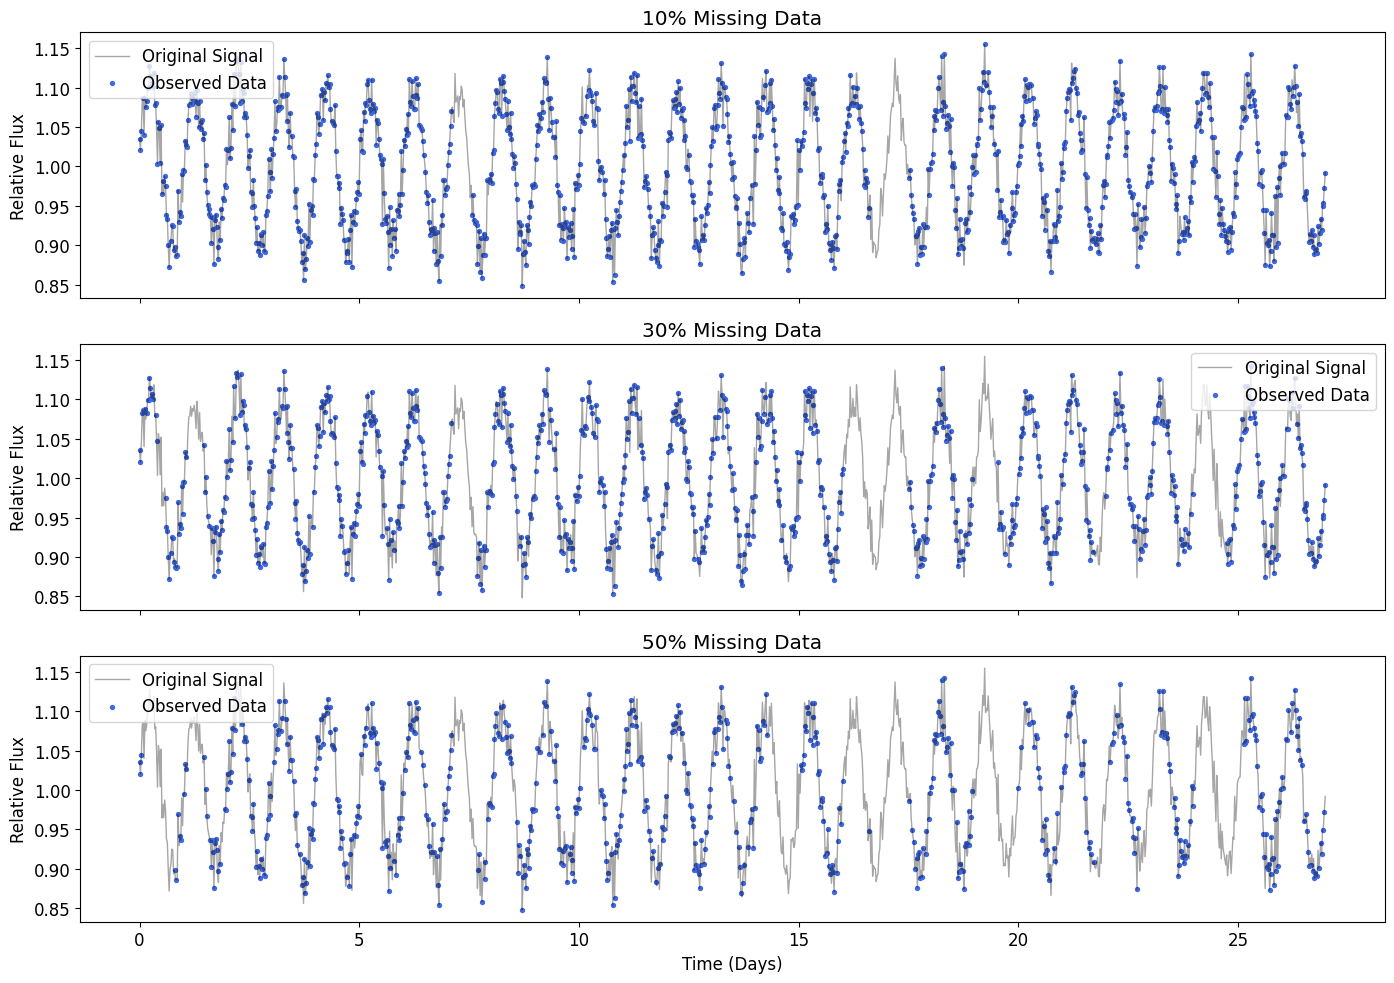

In [7]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 10),
    sharex=True
)

for ax, level in zip(axes, missing_levels):

    ax.plot(
        time,
        observed_flux,
        color="black",
        lw=1,
        alpha=0.35,
        label="Original Signal"
    )

    ax.scatter(
        time,
        datasets[level]["flux"],
        s=8,
        color="royalblue",
        label="Observed Data"
    )

    ax.set_title(
        f"{int(level*100)}% Missing Data"
    )

    ax.set_ylabel("Relative Flux")

    ax.legend()

plt.xlabel("Time (Days)")
plt.tight_layout()

plt.show()

- ## Visualize the Missing-Data Masks

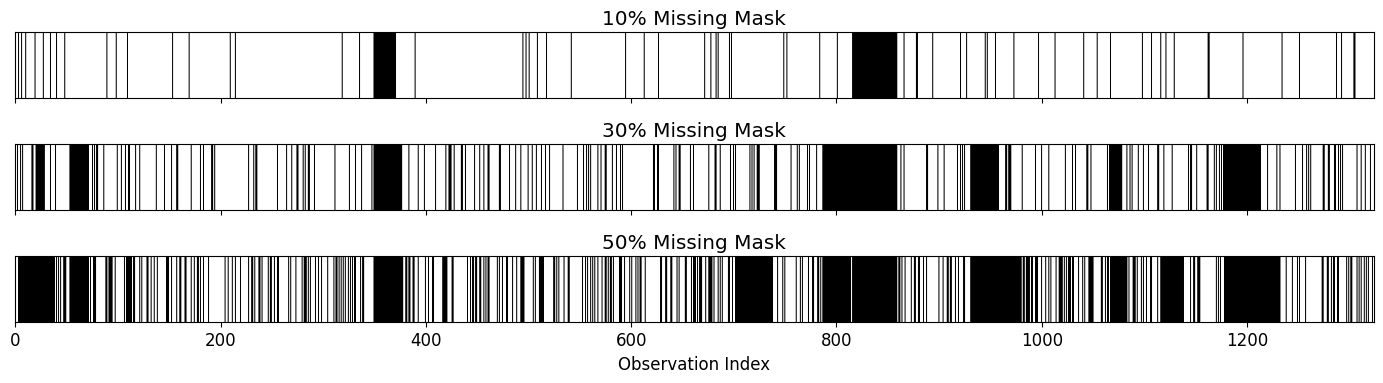

In [8]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 4),
    sharex=True
)

for ax, level in zip(axes, missing_levels):

    ax.imshow(
        datasets[level]["mask"].reshape(1, -1),
        cmap="gray",
        aspect="auto"
    )

    ax.set_title(
        f"{int(level*100)}% Missing Mask"
    )

    ax.set_yticks([])

plt.xlabel("Observation Index")

plt.tight_layout()

plt.show()

- ## Save the Corrupted Datasets

In [9]:
for level in missing_levels:

    output = pd.DataFrame({

        "time": time,

        "ideal_flux": ideal_flux,

        "observed_flux": observed_flux,

        "corrupted_flux": datasets[level]["flux"],

        "mask": datasets[level]["mask"]

    })

    filename = f"gap_{int(level*100)}.csv"

    output.to_csv(
        filename,
        index=False
    )

    print(f"Saved: {filename}")

Saved: gap_10.csv
Saved: gap_30.csv
Saved: gap_50.csv


- ## Summary Table

In [10]:
summary = []

for level in missing_levels:

    mask = datasets[level]["mask"]

    summary.append({

        "Missing (%)": int(level * 100),

        "Observed": np.sum(mask == 1),

        "Missing": np.sum(mask == 0)

    })

summary = pd.DataFrame(summary)

summary

,Missing (%),Observed,Missing
0,10,1192,132
1,30,927,397
2,50,662,662


- ## Save Masks Separately

In [12]:
for frac in missing_levels:

    pd.DataFrame({

        "mask": datasets[frac]["mask"]

    }).to_csv(

        f"mask_{int(frac*100)}.csv",

        index=False

    )